# M33 notebook 3a: peak counts for shared parameters across all fields

This notebook runs the peak-identification counting step from notebook 3 across all nine fields with one shared parameter set. Change the parameters in the next cell, run the notebook, and the final cells print the number of peaks per field and the total number of peaks.

By default this notebook only writes test outputs under `peak_parameter_tests/` and does not overwrite the production `final_peak_info/latest_peaks_<FIELD>.csv` files used by later notebooks.

In [4]:
from pathlib import Path
import sys

_here = Path.cwd().resolve()
_candidates = (_here, *_here.parents)
REPO_ROOT = next((candidate for candidate in _candidates if (candidate / "m33_pipeline").is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root from {Path.cwd()}")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from m33_pipeline.notebook_setup import prepare_notebook

REPO_ROOT = prepare_notebook(REPO_ROOT)
print(f"Notebook working directory set to: {REPO_ROOT}")

Notebook working directory set to: /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1


## Shared Parameters

These defaults are the base values used in `3_finalize_peak_detection.ipynb`: `lap=15`, `snrlim=6`, `bgbox=25`, `stdbox=3`, and `signoi=3.0`. All fields are evaluated with the same values below.

If you change `bgbox`, `stdbox`, or `signoi`, the corresponding threshold FITS files must already exist from notebook 2b.

In [5]:
FIELDS = ('NE', 'NW', 'SE', 'SW', 'F5', 'F6', 'F7',  'F8', 'F9')

# Base notebook-3 parameters. Change one or more of these and rerun all cells.
lap = 15
lap_sizebox = 15
threshold_sizebox = 1
snrlim = 6.0
bgbox = 25
stdbox = 3
signoi = 3.0

# Keep this False for parameter tests. Set True only if you intentionally want
# per-field test peak catalogues written in addition to the count summary.
SAVE_PEAK_CATALOGS = False

# Set True to make one diagnostic plot per field with peaks overlaid on the
# Halpha+[OIII] map. Plots are saved under OUTPUT_DIR / 'field_peak_plots'.
MAKE_FIELD_PLOTS = False

OUTPUT_DIR = Path('peak_parameter_tests')

# Threshold signal choice:
# - 'amp_sized': use AMP_sizd<threshold_sizebox>.fits for every field, matching the
#   visible notebook-3 threshold expression im_amp3_s - thres.
# - 'match_latest': same shared numerical parameters, but F6 uses
#   M33_<FIELD>_HaOIII_amp_nonan.fits as the threshold signal to match the
#   current latest_peaks_F6.csv count in final_peak_info.
THRESHOLD_SIGNAL_MODE = 'match_latest'

print('Fields:', ', '.join(FIELDS))
print('Shared parameters:')
print(f'  lap={lap}, lap_sizebox={lap_sizebox}, threshold_sizebox={threshold_sizebox}')
print(f'  snrlim={snrlim}, bgbox={bgbox}, stdbox={stdbox}, signoi={signoi}')
print(f'  threshold signal mode={THRESHOLD_SIGNAL_MODE}')
print(f'  make field plots={MAKE_FIELD_PLOTS}')

Fields: NE, NW, SE, SW, F5, F6, F7, F8, F9
Shared parameters:
  lap=15, lap_sizebox=15, threshold_sizebox=1
  snrlim=6.0, bgbox=25, stdbox=3, signoi=3.0
  threshold signal mode=match_latest
  make field plots=False


In [6]:
import numpy as np
import pandas as pd
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import display

OUTPUT_DIR.mkdir(exist_ok=True)


def _sf(value):
    if isinstance(value, float) and value.is_integer():
        return str(int(value))
    if isinstance(value, float):
        return f'{value:g}'.replace('.', 'p')
    return str(value).replace('.', 'p')


def _threshold_signoi_string(value):
    return f'{float(value):.1f}'


def field_paths(field):
    visual_dir = Path('peak_files') / f'data_for_visualisation_OIII+Ha_{field}'
    threshold_dir = Path('peak_files') / f'2-BG_Noi_Th_data_OIII+Ha_{field}'
    maps_dir = REPO_ROOT.parent / 'M33-Maps' / f'M33-{field}'
    return {
        'candidate_peak': visual_dir / f'A_PicL{lap}_sizd{lap_sizebox}.fits',
        'threshold_signal_sized': visual_dir / f'AMP_sizd{threshold_sizebox}.fits',
        'threshold_signal_raw': visual_dir / f'M33_{field}_HaOIII_amp_nonan.fits',
        'threshold': threshold_dir / f'Th_box{bgbox}_std{stdbox}_signoi{_threshold_signoi_string(signoi)}.fits',
        'amp': maps_dir / f'M33-{field}_SN3.LineMaps.map.Ha+OIII.1x1.amplitude.fits',
        'amp_err': maps_dir / f'M33-{field}_SN3.LineMaps.map.Ha+OIII.1x1.amplitude-err.fits',
        'display_map': visual_dir / f'M33_{field}_HaOIII_amp_nonan.fits',
    }


def threshold_signal_path(field, paths):
    if THRESHOLD_SIGNAL_MODE == 'amp_sized':
        return paths['threshold_signal_sized']
    if THRESHOLD_SIGNAL_MODE == 'match_latest':
        return paths['threshold_signal_raw'] if field == 'F6' else paths['threshold_signal_sized']
    raise ValueError("THRESHOLD_SIGNAL_MODE must be 'amp_sized' or 'match_latest'")


def check_required_files(fields=FIELDS):
    rows = []
    for field in fields:
        paths = field_paths(field)
        required = {
            'candidate_peak': paths['candidate_peak'],
            'threshold_signal': threshold_signal_path(field, paths),
            'threshold': paths['threshold'],
            'amp': paths['amp'],
            'amp_err': paths['amp_err'],
            'display_map': paths['display_map'],
        }
        for kind, path in required.items():
            rows.append({'field': field, 'kind': kind, 'path': str(path), 'exists': path.exists()})
    check = pd.DataFrame(rows)
    missing = check.loc[~check['exists']]
    if not missing.empty:
        display(missing)
        raise FileNotFoundError('Missing required input files. Generate missing threshold maps with notebook 2b, or adjust the shared parameters.')
    print(f'All required input files exist for {len(fields)} fields.')
    return check


input_file_check = check_required_files()

All required input files exist for 9 fields.


## Peak Counting Function

This applies the same core cuts as notebook 3:

1. Start from the Laplacian candidate peak map `A_PicL<lap>_sizd<lap_sizebox>.fits`.
2. Keep only candidates with `(Ha+OIII amplitude)/(Ha+OIII amplitude error) >= snrlim`.
3. Keep only candidates above the threshold map, using `AMP_sizd<threshold_sizebox>.fits - Th_box<bgbox>_std<stdbox>_signoi<signoi>.fits > 0`.

In [7]:
def identify_peaks_for_field(field):
    paths = field_paths(field)
    peak_map = fits.getdata(paths['candidate_peak']).astype(float)
    amp = fits.getdata(paths['amp']).astype(float)
    amp_err = fits.getdata(paths['amp_err']).astype(float)
    threshold = fits.getdata(paths['threshold']).astype(float)
    threshold_signal_file = threshold_signal_path(field, paths)
    threshold_signal = fits.getdata(threshold_signal_file).astype(float)

    with np.errstate(divide='ignore', invalid='ignore'):
        snr = amp / amp_err

    selected = peak_map.copy()
    selected[snr < snrlim] = np.nan
    selected[(threshold_signal - threshold) <= 0] = np.nan
    y, x = np.where(selected == 1)

    peaks = pd.DataFrame({
        'field': field,
        'y': y.astype(int),
        'x': x.astype(int),
        'peak_snr': snr[y, x],
        'threshold_excess': (threshold_signal - threshold)[y, x],
    })

    metadata = {
        'field': field,
        'n_peaks': len(peaks),
        'candidate_peak_file': str(paths['candidate_peak']),
        'threshold_signal_file': str(threshold_signal_file),
        'threshold_file': str(paths['threshold']),
        'amp_file': str(paths['amp']),
        'amp_err_file': str(paths['amp_err']),
    }
    return peaks, metadata


def parameter_tag():
    return (
        f'L{lap}_lapsize{lap_sizebox}_thsize{threshold_sizebox}'
        f'_snr{_sf(float(snrlim))}_bg{bgbox}_std{stdbox}_signoi{_sf(float(signoi))}'
        f'_{THRESHOLD_SIGNAL_MODE}'
    )

## Run All Fields

In [8]:
all_peak_tables = []
summary_rows = []
for field in FIELDS:
    peaks, metadata = identify_peaks_for_field(field)
    all_peak_tables.append(peaks)
    summary_rows.append(metadata)
    print(f'{field}: {len(peaks)} peaks')

all_peaks = pd.concat(all_peak_tables, ignore_index=True) if all_peak_tables else pd.DataFrame()
summary = pd.DataFrame(summary_rows)
summary['lap'] = lap
summary['lap_sizebox'] = lap_sizebox
summary['threshold_sizebox'] = threshold_sizebox
summary['snrlim'] = snrlim
summary['bgbox'] = bgbox
summary['stdbox'] = stdbox
summary['signoi'] = signoi
summary['threshold_signal_mode'] = THRESHOLD_SIGNAL_MODE

tag = parameter_tag()
summary_path = OUTPUT_DIR / f'peak_counts_{tag}.csv'
all_peaks_path = OUTPUT_DIR / f'peaks_all_fields_{tag}.csv'
summary.to_csv(summary_path, index=False)
all_peaks.to_csv(all_peaks_path, index=False)

if SAVE_PEAK_CATALOGS:
    per_field_dir = OUTPUT_DIR / f'per_field_peaks_{tag}'
    per_field_dir.mkdir(parents=True, exist_ok=True)
    for field, peaks in all_peaks.groupby('field', sort=False):
        peaks.to_csv(per_field_dir / f'peaks_{field}_{tag}.csv', index=False)
    print(f'Wrote per-field peak catalogues to {per_field_dir}')

print('\nWrote summary:', summary_path)
print('Wrote all-field peak table:', all_peaks_path)

NE: 499 peaks
NW: 736 peaks
SE: 482 peaks
SW: 600 peaks
F5: 519 peaks
F6: 176 peaks
F7: 561 peaks
F8: 247 peaks
F9: 176 peaks

Wrote summary: peak_parameter_tests/peak_counts_L15_lapsize15_thsize1_snr6_bg25_std3_signoi3_match_latest.csv
Wrote all-field peak table: peak_parameter_tests/peaks_all_fields_L15_lapsize15_thsize1_snr6_bg25_std3_signoi3_match_latest.csv


## Counts

In [9]:
counts = summary[['field', 'n_peaks']].copy()
total_peaks = int(counts['n_peaks'].sum())

print('Peak counts per field:')
display(counts)
print(f'Total peaks across {len(FIELDS)} fields: {total_peaks}')

Peak counts per field:


,field,n_peaks
0,NE,499
1,NW,736
2,SE,482
3,SW,600
4,F5,519
5,F6,176
6,F7,561
7,F8,247
8,F9,176


Total peaks across 9 fields: 3996


## Boundary Test Summaries

After running `M33_catalog_pipeline.py --stage region-tests`, this cell reads the isolated boundary-test summaries from `region_identification_testing/` and reports the final number of regions and average boundary sizes. These results are separate from the main catalog products.

In [10]:
REGION_TEST_ROOT = Path('region_identification_testing')

summary_files = sorted(REGION_TEST_ROOT.glob('*/tables/region_test_summary_*.csv'))
total_files = sorted(REGION_TEST_ROOT.glob('*/tables/region_test_totals_*.csv'))

if not summary_files:
    print('No completed boundary-test summaries found yet.')
    print('Run, for example:')
    print('  python M33_catalog_pipeline.py --stage region-tests --lap-sizeboxes 1 10 30')
else:
    boundary_summaries = pd.concat((pd.read_csv(path) for path in summary_files), ignore_index=True)
    display_cols = [
        'variant', 'field', 'lap_sizebox', 'signoi', 'input_peaks',
        'final_regions_after_boundary', 'mean_radius_areaeq_pc', 'median_radius_areaeq_pc',
    ]
    display(boundary_summaries[[col for col in display_cols if col in boundary_summaries.columns]])

    variant_summary = (
        boundary_summaries
        .groupby('variant', as_index=False)
        .agg(
            lap_sizebox=('lap_sizebox', 'first'),
            signoi=('signoi', 'first'),
            total_input_peaks=('input_peaks', 'sum'),
            total_final_regions_after_boundary=('final_regions_after_boundary', 'sum'),
            mean_field_radius_areaeq_pc=('mean_radius_areaeq_pc', 'mean'),
            median_field_radius_areaeq_pc=('median_radius_areaeq_pc', 'median'),
        )
        .sort_values(['lap_sizebox', 'signoi', 'variant'])
    )
    print('Variant-level summary from completed boundary tests:')
    display(variant_summary)

if total_files:
    boundary_totals = pd.concat((pd.read_csv(path) for path in total_files), ignore_index=True)
    print('All-region weighted totals from completed boundary tests:')
    display(boundary_totals)


,variant,field,lap_sizebox,signoi,input_peaks,final_regions_after_boundary,mean_radius_areaeq_pc,median_radius_areaeq_pc
0,L15_lapsize10_thsize1_snr6_bg25_std3_signoi3_m...,NW,10,3.0,1224,1216,13.340737,13.069849
1,L15_lapsize10_thsize1_snr6_bg25_std3_signoi3_m...,NE,10,3.0,814,809,12.378131,12.171910
2,L15_lapsize10_thsize1_snr6_bg25_std3_signoi3_m...,SW,10,3.0,1001,992,12.270092,11.965785
3,L15_lapsize10_thsize1_snr6_bg25_std3_signoi3_m...,SE,10,3.0,795,787,12.295189,11.942663
4,L15_lapsize10_thsize1_snr6_bg25_std3_signoi3_m...,F5,10,3.0,962,934,11.015734,10.713661
5,L15_lapsize10_thsize1_snr6_bg25_std3_signoi3_m...,F6,10,3.0,410,377,12.833531,12.825167
6,L15_lapsize10_thsize1_snr6_bg25_std3_signoi3_m...,F7,10,3.0,965,960,12.016120,11.838048
7,L15_lapsize10_thsize1_snr6_bg25_std3_signoi3_m...,F8,10,3.0,387,382,12.234287,12.068488
8,L15_lapsize10_thsize1_snr6_bg25_std3_signoi3_m...,F9,10,3.0,284,277,11.863348,11.228766
9,L15_lapsize15_thsize1_snr6_bg25_std3_signoi3_m...,NW,15,3.0,736,735,15.188108,14.512887


Variant-level summary from completed boundary tests:


,variant,lap_sizebox,signoi,total_input_peaks,total_final_regions_after_boundary,mean_field_radius_areaeq_pc,median_field_radius_areaeq_pc
2,L15_lapsize5_thsize1_snr6_bg25_std3_signoi3_ma...,5,3.0,14697,14297,9.778652,9.454231
0,L15_lapsize10_thsize1_snr6_bg25_std3_signoi3_m...,10,3.0,6842,6734,12.249685,11.965785
1,L15_lapsize15_thsize1_snr6_bg25_std3_signoi3_m...,15,3.0,3996,3961,13.790314,13.069849


All-region weighted totals from completed boundary tests:


,variant,n_fields,total_input_peaks,total_final_regions_after_boundary,mean_radius_areaeq_pc_all_regions,summary_csv,median_radius_areaeq_pc_all_regions
0,L15_lapsize10_thsize1_snr6_bg25_std3_signoi3_m...,9,6842,6734,12.281934,/Users/emmajarvis/Documents/SIGNALS/M33/PAPER1...,11.919496
1,L15_lapsize15_thsize1_snr6_bg25_std3_signoi3_m...,9,3996,3961,13.770493,/Users/emmajarvis/Documents/SIGNALS/M33/PAPER1...,13.175168
2,L15_lapsize5_thsize1_snr6_bg25_std3_signoi3_ma...,9,14697,14297,9.755185,/Users/emmajarvis/Documents/SIGNALS/M33/PAPER1...,9.316250


## Field Peak Overlay Plots

If `MAKE_FIELD_PLOTS = True`, this cell writes one plot per field with the identified peaks overlaid on the Halpha+[OIII] map. The title records the field count and the parameter tag used for the run.

In [11]:
def local_lognorm(data, p_lo=3.0, p_hi=99.7):
    positive = data[np.isfinite(data) & (data > 0)]
    if positive.size == 0:
        return None
    vmin, vmax = np.nanpercentile(positive, [p_lo, p_hi])
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin:
        vmin, vmax = np.nanmin(positive), np.nanmax(positive)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin:
        return None
    return LogNorm(vmin=max(vmin, np.nextafter(0, 1)), vmax=vmax)


def plot_field_peaks(field, peaks, out_dir):
    paths = field_paths(field)
    image = fits.getdata(paths['display_map']).astype(float)
    norm = local_lognorm(image)

    fig, ax = plt.subplots(figsize=(8, 8))
    if norm is None:
        im = ax.imshow(image, origin='lower', cmap='gray')
    else:
        im = ax.imshow(image, origin='lower', cmap='gray', norm=norm)
    ax.scatter(
        peaks['x'], peaks['y'],
        s=18, facecolors='none', edgecolors='crimson', linewidths=0.8,
        label=f'Peaks: {len(peaks)}',
    )
    ax.set_xlabel('x pixel')
    ax.set_ylabel('y pixel')
    ax.set_title(
        f'{field}: {len(peaks)} peaks\n'
        f'L{lap}, snr{snrlim:g}, bg{bgbox}, std{stdbox}, signoi{signoi:g}, mode={THRESHOLD_SIGNAL_MODE}',
        fontsize=11,
    )
    ax.legend(loc='upper right', frameon=True, framealpha=0.85)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Halpha+[OIII] amplitude')
    fig.tight_layout()

    out_path = out_dir / f'{field}_peaks_{parameter_tag()}.png'
    fig.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.close(fig)
    return out_path


if MAKE_FIELD_PLOTS:
    plot_dir = OUTPUT_DIR / 'field_peak_plots' / parameter_tag()
    plot_dir.mkdir(parents=True, exist_ok=True)
    plot_paths = []
    for field in FIELDS:
        field_peaks = all_peaks.loc[all_peaks['field'].eq(field)].copy()
        plot_paths.append(plot_field_peaks(field, field_peaks, plot_dir))
    print('Wrote field peak overlay plots:')
    for path in plot_paths:
        print(f'  {path}')
else:
    print('MAKE_FIELD_PLOTS is False; skipped field peak overlay plots.')

MAKE_FIELD_PLOTS is False; skipped field peak overlay plots.


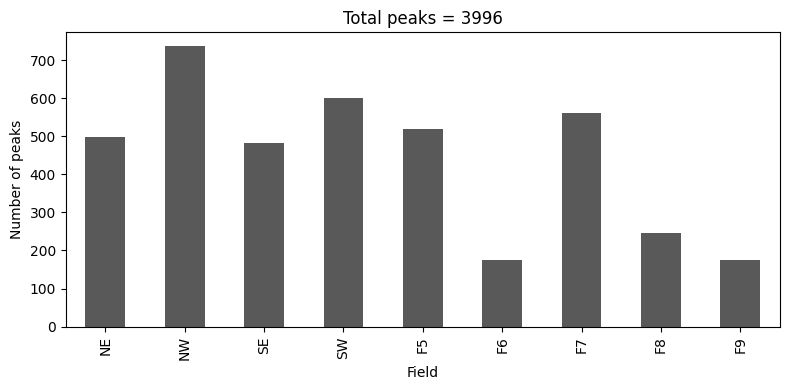

In [12]:
# Optional quick bar plot of the counts.
ax = counts.plot.bar(x='field', y='n_peaks', legend=False, figsize=(8, 4), color='0.35')
ax.set_xlabel('Field')
ax.set_ylabel('Number of peaks')
ax.set_title(f'Total peaks = {total_peaks}')
ax.figure.tight_layout()